In [1]:
!pip install deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 14.9 MB/s eta 0:00:00


In [2]:
from abc import update_abstractmethods
import deepxde as dde
import numpy as np
from deepxde.backend import tf
import matplotlib.pyplot as plt

No backend selected.
Finding available backend...
Found tensorflow
Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "tensorflow". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


Enable just-in-time compilation with XLA.



In [3]:
pi = np.pi
geom = dde.geometry.Rectangle(xmin=[0, -pi], xmax=[pi, pi])
timedomain = dde.geometry.TimeDomain(0, 1)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

In [4]:
lam_init = -1
lam = dde.Variable(float(lam_init))

def pde(x, u):
  u_t = dde.grad.jacobian(u, x, i=0, j=2)
  u_xx = dde.grad.hessian(u, x, i=0, j=0)
  u_yy = dde.grad.hessian(u, x, i=1, j=1)
  y = x[:, 1:2]
  t = x[:, 2:3]
  return u_t - (3/2)*(u_xx + u_yy) - \
    lam * tf.exp(-21*t/10) * tf.cos(3*y/5) \
    - 138 * tf.exp(-21*t/10) * tf.sin(9*x[:, 0:1]/5) / 25

In [5]:
def initial_cond(x, on_initial):
  return on_initial and np.isclose(x[2], 0)

def fic(x):
  return 2 * tf.sin(9*x[:, 0:1]/5) + \
    11 * tf.cos(3*x[:, 1:2]/5) / 5 + 7/5

ic = dde.icbc.IC(geomtime, fic, initial_cond)

def boundary_left(x, on_boundary):
    return on_boundary and np.isclose(x[0], 0)
def boundary_right(x, on_boundary):
    return on_boundary and np.isclose(x[0], pi)
def boundary_bottom(x, on_boundary):
    return on_boundary and np.isclose(x[1], -pi)
def boundary_top(x, on_boundary):
    return on_boundary and np.isclose(x[1], pi)

def fleft(x):
  return - 18 * tf.exp(-21*x[:, 2:3]/10) /5
def fright(x):
  exp = tf.exp(-21*x[:, 2:3]/10)
  return 9*exp/10 + 9*tf.cast(tf.sqrt(5.0), tf.float32)*exp/10
def ftopbottom(x):
  exp = tf.exp(-21*x[:, 2:3]/10)
  return 7/5 + 2*exp*tf.sin(9*x[:, 0:1]/5) - \
    11*tf.cast(tf.sqrt(5.0), tf.float32)*exp/20 + 11*exp/20


bc_left = dde.icbc.NeumannBC(geomtime, fleft, boundary_left)
bc_right = dde.icbc.NeumannBC(geomtime, fright, boundary_right)
bc_bottom = dde.icbc.DirichletBC(geomtime, ftopbottom, boundary_bottom)
bc_top = dde.icbc.DirichletBC(geomtime, ftopbottom, boundary_top)

In [6]:
file_data = np.load('var-05.npz')
xyt = file_data['xyt']
u = file_data['u']
bc_points = dde.icbc.PointSetBC(xyt, u)

data = dde.data.TimePDE(
    geomtime,
    pde,
    [ic, bc_left, bc_right, bc_top, bc_bottom, bc_points],
    num_domain=1000,
    num_boundary=500,
    num_initial=700,
    anchors=xyt,
    train_distribution="uniform",
    num_test=1000,
)

In [7]:
layer_size = [3] + [32] * 4 + [1]
activation = "tanh"
initializer = "Glorot uniform"
net = dde.nn.FNN(layer_size, activation, initializer)
model = dde.Model(data, net)

Compiling model...
'compile' took 0.011841 s

Training model...

Step      Train loss                                                                Test loss                                                                 Test metric
0         [6.81e-01, 7.03e+00, 1.12e+00, 1.01e+00, 1.38e+00, 1.28e+00, 1.22e+00]    [3.56e+00, 7.03e+00, 1.12e+00, 1.01e+00, 1.38e+00, 1.28e+00, 1.22e+00]    []  
0 [-1.00e+00]
1000      [1.09e-02, 1.33e-03, 6.37e-04, 1.89e-02, 5.20e-04, 2.91e-04, 3.66e-04]    [3.64e-01, 1.33e-03, 6.37e-04, 1.89e-02, 5.20e-04, 2.91e-04, 3.66e-04]    []  
1000 [-1.35e+00]
2000      [5.43e-03, 6.99e-04, 3.05e-04, 1.39e-02, 3.19e-04, 3.37e-04, 2.37e-04]    [1.94e-01, 6.99e-04, 3.05e-04, 1.39e-02, 3.19e-04, 3.37e-04, 2.37e-04]    []  
2000 [-1.89e+00]
3000      [3.05e-03, 3.01e-03, 2.46e-04, 1.04e-02, 5.15e-04, 5.32e-04, 3.93e-04]    [9.53e-02, 3.01e-03, 2.46e-04, 1.04e-02, 5.15e-04, 5.32e-04, 3.93e-04]    []  
3000 [-2.39e+00]

Best model at step 3000:
  train loss: 1.81e-02

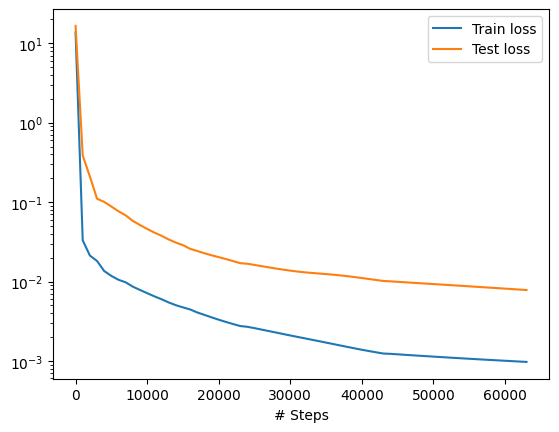

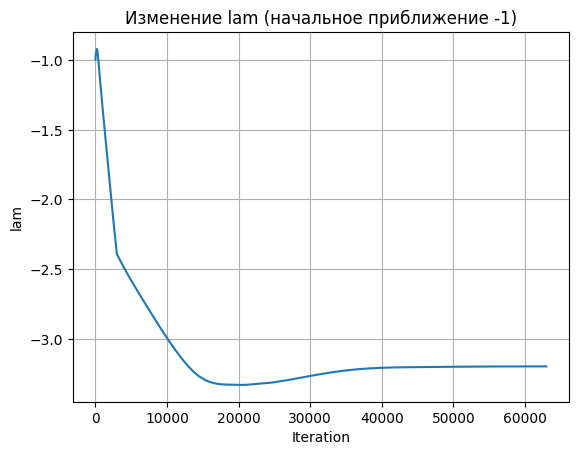

Финальное lam для запуска с начальным -1: -3.195225238800049


In [8]:
variable_cb = dde.callbacks.VariableValue(lam, period=1000)
resampler_cb = dde.callbacks.PDEPointResampler(period=1000)
lam_history = []
class LambdaHistory(dde.callbacks.Callback):
  def on_epoch_end(self):
      val = lam.value() if callable(lam.value) else lam.value
      if hasattr(val, 'numpy'):
          val = val.numpy()
      lam_history.append(float(val))
history_cb = LambdaHistory()

model.compile("adam", lr=0.001, external_trainable_variables=lam)
losshistory, train_state = model.train(iterations=3000, callbacks=[variable_cb, resampler_cb, history_cb])

model.compile("adam", lr=1e-4, external_trainable_variables=lam)
losshistory, train_state = model.train(iterations=20000, callbacks=[variable_cb, resampler_cb, history_cb])

model.compile("adam", lr=1e-5, external_trainable_variables=lam)
losshistory, train_state = model.train(iterations=20000, callbacks=[variable_cb, resampler_cb, history_cb])

model.compile("adam", lr=1e-6, external_trainable_variables=lam)
losshistory, train_state = model.train(iterations=20000, callbacks=[variable_cb, resampler_cb, history_cb])

dde.saveplot(losshistory, train_state, issave=True, isplot=True)

plt.figure()
plt.plot(lam_history)
plt.xlabel('Iteration')
plt.ylabel('lam')
plt.title(f'Изменение lam (начальное приближение {lam_init})')
plt.grid(True)
plt.savefig(f'lambda_history.png')
plt.show()

val = lam.value() if callable(lam.value) else lam.value
if hasattr(val, 'numpy'):
    val = val.numpy()
final_lam = float(val)
print(f"Финальное lam для запуска с начальным {lam_init}: {final_lam}")